# CSP Scanner — Historische Analyse (DuckDB)

Dieses Notebook liest direkt aus der DuckDB-Datenbank.  
Kein IB-Connect notwendig — reine Datenanalyse.

**Voraussetzung:** Mindestens ein Scan-Lauf wurde mit `store.enabled: true` in `settings.yaml` ausgeführt.

## 0 — Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.store import ScanStore

DB_PATH = PROJECT_ROOT / 'data' / 'csp_history.duckdb'

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)

store = ScanStore(DB_PATH)
print(f'Connected to: {store.path}')

Connected to: /Users/stefan_pro/development/Claude/csp_scanner/data/csp_history.duckdb


---
## 1 — Scan-Runs Übersicht

In [2]:
df_runs = store.runs()
print(f'{len(df_runs)} Runs in der Datenbank:\n')
df_runs

4 Runs in der Datenbank:



,run_id,run_ts,n_tickers,n_candidates,avg_yield_pct,avg_score,n_attraktiv,n_mittel,n_vorsicht
0,20260420_191006,2026-04-20 19:10:06.143728,3,50,7.6800,49.0000,12,14,24
1,20260420_151256,2026-04-20 15:12:56.000000,2,50,7.8300,49.0000,14,11,25
2,20260419_123440,2026-04-19 12:34:40.000000,0,0,NaN,NaN,0,0,0
3,20260419_121030,2026-04-19 12:10:30.000000,0,0,NaN,NaN,0,0,0


---
## 2 — Letzter Run: Top-Kandidaten

In [3]:
df_latest = store.query('''
    SELECT
        symbol, expiry_date, dte, strike, spot,
        ROUND(moneyness   * 100, 2) AS moneyness_pct,
        ROUND(ann_yield   * 100, 2) AS ann_yield_pct,
        ROUND(total_yield * 100, 2) AS total_yield_pct,
        ROUND(spread_pct  * 100, 2) AS spread_pct,
        iv, delta, breakeven, score, rating
    FROM latest_run
    ORDER BY score DESC
''').df()

print(f'{len(df_latest)} Kandidaten im letzten Run\n')
df_latest.head(20)

50 Kandidaten im letzten Run



,symbol,expiry_date,dte,strike,spot,moneyness_pct,ann_yield_pct,total_yield_pct,spread_pct,iv,delta,breakeven,score,rating
0,PLTR,2026-12-18,241,97.5000,145.3462,-32.9200,9.5100,13.5100,2.4500,0.6066,-0.1353,91.3750,83,Attraktiv
1,PLTR,2026-12-18,241,100.0000,145.3462,-31.2000,10.1100,14.1100,2.2500,0.6019,-0.1457,93.3250,82,Attraktiv
2,PLTR,2026-11-20,213,100.0000,145.3462,-31.2000,10.2400,14.2400,2.5100,0.6080,-0.1402,94.0250,81,Attraktiv
3,PLTR,2027-12-17,605,100.0000,145.3500,-31.2000,9.4400,13.4400,2.5600,NaN,NaN,84.3500,79,Attraktiv
4,PLTR,2027-01-15,269,100.0000,145.3500,-31.2000,9.9100,13.9100,2.7400,NaN,NaN,92.7000,78,Attraktiv
5,PLTR,2028-01-21,640,100.0000,145.3462,-31.2000,9.2700,13.2700,1.8500,0.5977,-0.1761,83.7500,77,Attraktiv
6,PLTR,2027-03-19,332,100.0000,145.3462,-31.2000,10.0900,14.0900,2.7200,0.5956,-0.1603,90.8250,76,Attraktiv
7,PLTR,2027-01-15,269,97.5000,145.3500,-32.9200,9.3900,13.3900,2.9600,NaN,NaN,90.7500,75,Attraktiv
8,PLTR,2027-03-19,332,90.0000,145.3462,-38.0800,8.1500,12.1500,2.2500,0.6118,-0.1221,83.3250,74,Attraktiv
9,PLTR,2027-01-15,269,92.5000,145.3500,-36.3600,8.3200,12.3200,2.6400,NaN,NaN,86.8250,71,Attraktiv


---
## 3 — Rendite-Entwicklung pro Symbol (alle Runs)

In [4]:
df_trend = store.query('''
    SELECT
        symbol,
        run_ts::DATE                    AS scan_date,
        ROUND(AVG(ann_yield)  * 100, 3) AS avg_yield_pct,
        ROUND(MAX(ann_yield)  * 100, 3) AS max_yield_pct,
        ROUND(AVG(iv)         * 100, 3) AS avg_iv_pct,
        ROUND(AVG(score),     0)        AS avg_score,
        COUNT(*)                        AS n_candidates
    FROM scan_candidates
    GROUP BY symbol, scan_date
    ORDER BY symbol, scan_date
''').df()

print(df_trend.to_string(index=False))

symbol  scan_date  avg_yield_pct  max_yield_pct  avg_iv_pct  avg_score  n_candidates
  NVDA 2026-04-20         6.4070         7.3840     46.2990    28.0000            50
  PLTR 2026-04-20         9.1100        10.4100     60.5850    70.0000            50


In [ ]:
# Trend-Chart (nur wenn mehrere Runs vorhanden)
symbols = df_trend['symbol'].unique()

if len(df_runs) > 1:
    fig, axes = plt.subplots(len(symbols), 1,
                             figsize=(12, 4 * len(symbols)),
                             squeeze=False)
    for ax, sym in zip(axes[:, 0], symbols):
        grp = df_trend[df_trend['symbol'] == sym]
        ax.plot(grp['scan_date'], grp['avg_yield_pct'], marker='o', label='Ø Ann. Rendite %')
        ax.plot(grp['scan_date'], grp['avg_iv_pct'],    marker='s', linestyle='--', label='Ø IV %')
        ax.set_title(sym, fontsize=13, fontweight='bold')
        ax.set_ylabel('%')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
        ax.legend()
        ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print('Noch nicht genug Runs für einen Trend-Chart (mindestens 2 Runs benötigt).')

---
## 4 — Filtered Query: Attraktive PLTR-Kandidaten (Beispiel)

In [8]:
# Alle PLTR-Kandidaten mit Yield >= 9% aus allen Runs
df_pltr = store.candidates(symbol='PLTR', min_yield=0.09).df()

cols = ['run_ts', 'expiry_date', 'dte', 'strike', 'spot',
        'ann_yield', 'total_yield', 'breakeven', 'score', 'rating']
print(f'{len(df_pltr)} PLTR-Kandidaten mit Yield >= 9%:\n')
df_pltr[cols].head(20)

28 PLTR-Kandidaten mit Yield >= 9%:



,run_ts,expiry_date,dte,strike,spot,ann_yield,total_yield,breakeven,score,rating
0,2026-04-20 15:12:56.000000,2026-12-18,241,97.5000,144.5200,0.0967,0.1367,91.2750,87,Attraktiv
1,2026-04-20 15:12:56.000000,2026-11-20,213,100.0000,144.4061,0.1041,0.1441,93.9250,84,Attraktiv
2,2026-04-20 15:12:56.000000,2026-12-18,241,100.0000,144.5200,0.1030,0.1430,93.2000,84,Attraktiv
3,2026-04-20 15:12:56.000000,2027-03-19,332,100.0000,144.4061,0.1025,0.1425,90.6750,83,Attraktiv
4,2026-04-20 19:10:06.143728,2026-12-18,241,97.5000,145.3462,0.0951,0.1351,91.3750,83,Attraktiv
5,2026-04-20 19:10:06.143728,2026-12-18,241,100.0000,145.3462,0.1011,0.1411,93.3250,82,Attraktiv
6,2026-04-20 19:10:06.143728,2026-11-20,213,100.0000,145.3462,0.1024,0.1424,94.0250,81,Attraktiv
7,2026-04-20 15:12:56.000000,2027-01-15,269,97.5000,144.4061,0.0953,0.1353,90.6500,80,Attraktiv
8,2026-04-20 19:10:06.143728,2027-12-17,605,100.0000,145.3500,0.0944,0.1344,84.3500,79,Attraktiv
9,2026-04-20 19:10:06.143728,2027-01-15,269,100.0000,145.3500,0.0991,0.1391,92.7000,78,Attraktiv


---
## 5 — Cross-Run: Beste Strike/Expiry-Kombination

Welche Kombinationen tauchen **konsistent** als attraktiv auf?

In [5]:
df_consistent = store.query('''
    SELECT
        symbol,
        strike,
        expiry,
        COUNT(DISTINCT run_id)          AS n_runs_seen,
        ROUND(AVG(ann_yield)  * 100, 2) AS avg_yield_pct,
        ROUND(AVG(score), 0)            AS avg_score,
        ROUND(AVG(delta), 4)            AS avg_delta,
        ROUND(AVG(iv)     * 100, 2)     AS avg_iv_pct
    FROM scan_candidates
    GROUP BY symbol, strike, expiry
    HAVING COUNT(DISTINCT run_id) > 1
    ORDER BY n_runs_seen DESC, avg_score DESC
    LIMIT 30
''').df()

if df_consistent.empty:
    print('Noch nicht genug Runs für Cross-Run-Analyse (mindestens 2 Runs mit gleichen Kontrakten).')
else:
    print(f'{len(df_consistent)} wiederkehrende Kombinationen:\n')
    df_consistent

30 wiederkehrende Kombinationen:



---
## 6 — Risk/Reward-Matrix (letzter Run)

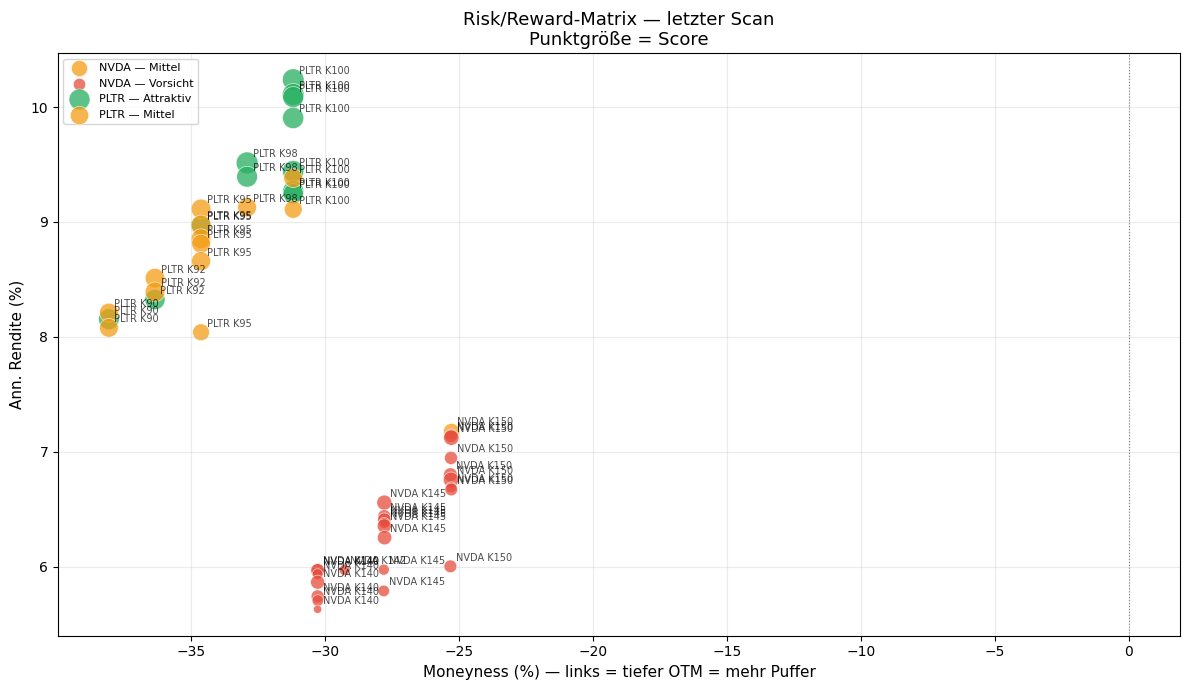

In [6]:
df_matrix = store.query('''
    SELECT symbol, strike, dte,
        ann_yield, moneyness, score, rating, iv, delta
    FROM latest_run
    WHERE ann_yield IS NOT NULL AND moneyness IS NOT NULL
''').df()

colors = {'Attraktiv': '#27ae60', 'Mittel': '#f39c12', 'Vorsicht': '#e74c3c'}
symbols = df_matrix['symbol'].unique()

fig, ax = plt.subplots(figsize=(12, 7))
for sym in symbols:
    grp = df_matrix[df_matrix['symbol'] == sym]
    for rating, color in colors.items():
        sub = grp[grp['rating'] == rating]
        if sub.empty:
            continue
        sc = ax.scatter(
            sub['moneyness'] * 100,
            sub['ann_yield'] * 100,
            c=color,
            s=sub['score'] * 3,
            alpha=0.75,
            label=f'{sym} — {rating}',
            edgecolors='white', linewidth=0.5,
        )
        for _, row in sub.iterrows():
            ax.annotate(
                f"{sym} K{row['strike']:.0f}",
                (row['moneyness'] * 100, row['ann_yield'] * 100),
                fontsize=7, alpha=0.7, xytext=(4, 4), textcoords='offset points',
            )

ax.set_xlabel('Moneyness (%) — links = tiefer OTM = mehr Puffer', fontsize=11)
ax.set_ylabel('Ann. Rendite (%)', fontsize=11)
ax.set_title('Risk/Reward-Matrix — letzter Scan\nPunktgröße = Score', fontsize=13)
ax.axvline(0, color='grey', linestyle=':', linewidth=0.8)
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

---
## 7 — Freie SQL-Query

Direkte DuckDB-Abfrage — volle SQL-Power auf allen historischen Daten.

In [7]:
# Beispiel: Top-10 Kandidaten aller Zeit nach Score
df_sql = store.query('''
    SELECT
        run_ts::DATE AS scan_date,
        symbol,
        expiry_date,
        dte,
        strike,
        ROUND(ann_yield * 100, 2)   AS yield_pct,
        ROUND(moneyness * 100, 2)   AS moneyness_pct,
        score,
        rating
    FROM scan_candidates
    ORDER BY score DESC
    LIMIT 10
''').df()

df_sql

,scan_date,symbol,expiry_date,dte,strike,yield_pct,moneyness_pct,score,rating
0,2026-04-20,PLTR,2026-12-18,241,97.5000,9.6700,-32.5400,87,Attraktiv
1,2026-04-20,PLTR,2026-11-20,213,100.0000,10.4100,-30.7500,84,Attraktiv
2,2026-04-20,PLTR,2026-12-18,241,100.0000,10.3000,-30.8100,84,Attraktiv
3,2026-04-20,PLTR,2027-03-19,332,100.0000,10.2500,-30.7500,83,Attraktiv
4,2026-04-20,PLTR,2026-12-18,241,97.5000,9.5100,-32.9200,83,Attraktiv
5,2026-04-20,PLTR,2026-12-18,241,100.0000,10.1100,-31.2000,82,Attraktiv
6,2026-04-20,PLTR,2026-11-20,213,100.0000,10.2400,-31.2000,81,Attraktiv
7,2026-04-20,PLTR,2027-01-15,269,97.5000,9.5300,-32.4800,80,Attraktiv
8,2026-04-20,PLTR,2027-12-17,605,100.0000,9.4400,-31.2000,79,Attraktiv
9,2026-04-20,PLTR,2027-01-15,269,100.0000,9.9100,-31.2000,78,Attraktiv


In [10]:
# Disconnect (optional — GC räumt automatisch auf)
store.close()
print('Store geschlossen.')

Store geschlossen.
